In [3]:
# Data Preparation for Machine Learning Models
# This notebook generates spatiotemporal datasets for autoencoder and MLP training

import numpy as np
import torch
import xarray as xr
import matplotlib.pyplot as plt
from GetData import get_train_data

# Training and Testing Data Generation

This notebook prepares spatiotemporal datasets for machine learning models by extracting multi-point, multi-timestep samples from the ERA5 climate data. Two types of datasets are generated:

1. **Autoencoder Data**: Spatiotemporal feature extraction for dimensionality reduction
2. **MLP Data**: Input-output pairs for supervised wave parameter prediction

## 1. Autoencoder Dataset Preparation

Extract spatiotemporal neighborhoods from the dataset for training the autoencoder. Each sample consists of a 3×3 spatial grid over multiple time steps.

In [7]:
# Configuration parameters
VARIABLES = ["u10", "v10", "mwp", "swh",  "mwd_sin", "mwd_cos"]
N_TRAIN_SAMPLES = 10000
N_TEST_SAMPLES = 2000
NEIGH_LAT, NEIGH_LON = 1, 1  # Creates 3×3 spatial grid
TIME_HORIZON = 2  # Number of historical time steps
OUTPUT_FOLDER = 'dataset_final'

# Load training dataset
ds_train = xr.open_dataset("dataset_train/combined2.nc")
Xs = ds_train[VARIABLES].to_array().values

print("Dataset Configuration")
print("=" * 50)
print(f"Variables: {VARIABLES}")
print(f"Dataset shape: {Xs.shape}")
print(f"Spatial neighborhood: {2*NEIGH_LAT+1}×{2*NEIGH_LON+1} grid")
print(f"Temporal horizon: {TIME_HORIZON} time steps")

# Generate training samples
print(f"\nGenerating {N_TRAIN_SAMPLES} training samples...")
train_data, train_indexes = get_train_data(
    ds_train, Xs, N_TRAIN_SAMPLES, 
    neigh_lat=NEIGH_LAT, neigh_lon=NEIGH_LON, 
    time_horizon=TIME_HORIZON
)
train_data = np.array(train_data)

# Load test dataset
ds_test = xr.open_dataset("dataset_test/combined2.nc")

# Generate test samples
print(f"Generating {N_TEST_SAMPLES} test samples...")
test_data, test_indexes = get_train_data(
    ds_test, Xs, N_TEST_SAMPLES, 
    neigh_lat=NEIGH_LAT, neigh_lon=NEIGH_LON, 
    time_horizon=TIME_HORIZON
)
test_data = np.array(test_data)

print("\nData Generation Complete")
print("=" * 50)
print(f"Training data shape: {train_data.shape}")
print(f"Testing data shape: {test_data.shape}")
print(f"Features per sample: {train_data.shape[1]}")

Dataset Configuration
Variables: ['u10', 'v10', 'mwp', 'swh', 'mwd_sin', 'mwd_cos']
Dataset shape: (6, 105, 6624)
Spatial neighborhood: 3×3 grid
Temporal horizon: 2 time steps

Generating 10000 training samples...
Progress: |==============================| 10000/10000 (100.0%)Generating 2000 test samples...
Progress: |==============================| 2000/2000 (100.0%)
Data Generation Complete
Training data shape: (10000, 108)
Testing data shape: (2000, 108)
Features per sample: 108


In [8]:
# Save autoencoder datasets
train_file = f"{OUTPUT_FOLDER}/AE_train_data_{N_TRAIN_SAMPLES}_{VARIABLES}.npy"
test_file = f"{OUTPUT_FOLDER}/AE_test_data_{N_TEST_SAMPLES}_{VARIABLES}.npy"

np.save(train_file, train_data)
np.save(test_file, test_data)

print("Autoencoder datasets saved:")
print(f"  Training: {train_file}")
print(f"  Testing: {test_file}")

Autoencoder datasets saved:
  Training: dataset_final/AE_train_data_10000_['u10', 'v10', 'mwp', 'swh', 'mwd_sin', 'mwd_cos'].npy
  Testing: dataset_final/AE_test_data_2000_['u10', 'v10', 'mwp', 'swh', 'mwd_sin', 'mwd_cos'].npy


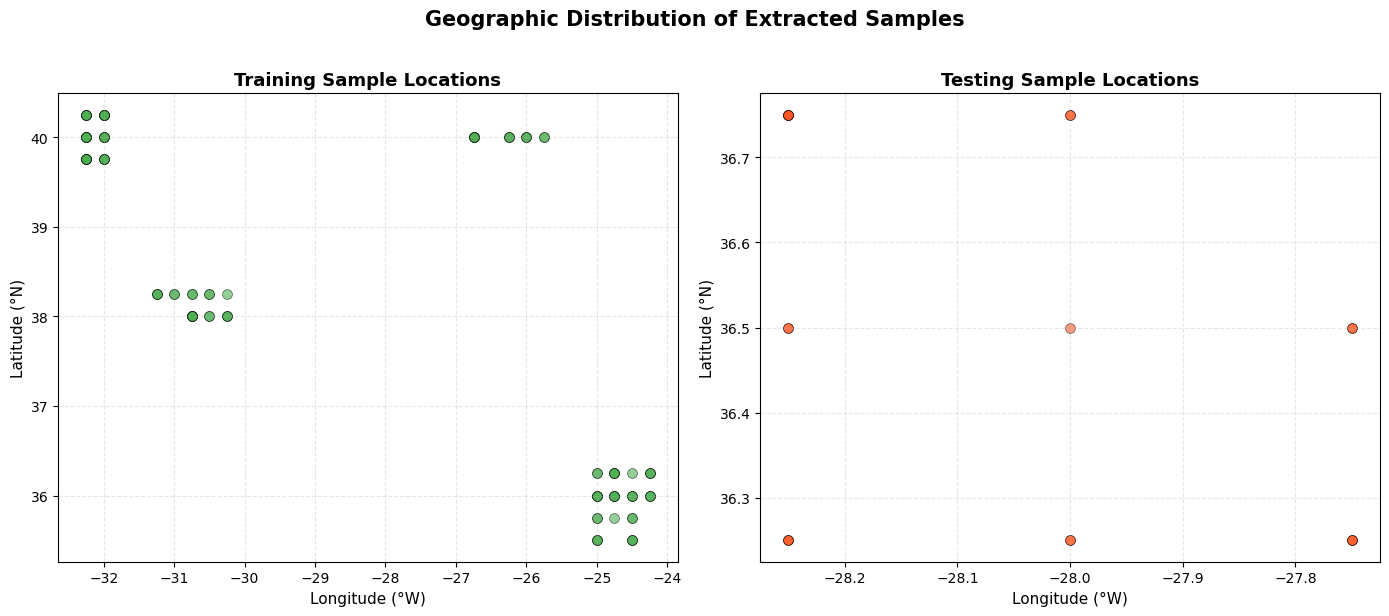

Training samples: 100 locations
Testing samples: 20 locations


In [30]:
### 1.1 Spatial Distribution of Samples

# Visualize geographic distribution of extracted samples
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Training data locations
axes[0].scatter(np.array(train_indexes)[:, 1], np.array(train_indexes)[:, 0], 
                alpha=0.6, s=50, c='#4CAF50', edgecolors='black', linewidth=0.5)
axes[0].set_title('Training Sample Locations', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Longitude (°W)', fontsize=11)
axes[0].set_ylabel('Latitude (°N)', fontsize=11)
axes[0].grid(True, alpha=0.3, linestyle='--')

# Testing data locations
axes[1].scatter(np.array(test_indexes)[:, 1], np.array(test_indexes)[:, 0], 
                alpha=0.6, s=50, c='#FF5722', edgecolors='black', linewidth=0.5)
axes[1].set_title('Testing Sample Locations', fontsize=13, fontweight='bold')    
axes[1].set_xlabel('Longitude (°W)', fontsize=11)
axes[1].set_ylabel('Latitude (°N)', fontsize=11)
axes[1].grid(True, alpha=0.3, linestyle='--')

plt.suptitle('Geographic Distribution of Extracted Samples', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Training samples: {len(train_indexes)} locations")
print(f"Testing samples: {len(test_indexes)} locations")

## 2. MLP Dataset Preparation

Generate supervised learning datasets for the Multi-Layer Perceptron model. Each sample consists of:
- **Input (X)**: Spatiotemporal features from historical time steps
- **Target (y)**: Wave parameters at the prediction horizon

### 2.1 Data Extraction Function

In [4]:
def get_data_MLP2(ds, vars, vars_pred, predicted_horizon=1, 
                  neigh_lat=1, neigh_lon=1, time_horizon=2, n_data=1000):
    """
    Extract spatiotemporal input-output pairs for MLP training.
    
    Args:
        ds (xr.Dataset): Source dataset
        vars (list): Input variable names
        vars_pred (list): Target variable names (subset of vars)
        predicted_horizon (int): Steps ahead to predict
        neigh_lat, neigh_lon (int): Spatial neighborhood radius
        time_horizon (int): Number of historical time steps
        n_data (int): Number of samples to generate
    
    Returns:
        tuple: (X, y) where X is input features and y is target values
    """
    # Extract variable arrays
    Xs = ds[vars].to_array().values
    
    # Generate spatiotemporal samples
    list_data, list_index = get_train_data(
        ds, Xs, n_data, neigh_lat, neigh_lon, 
        time_horizon + predicted_horizon
    )
    data = np.array(list_data)
    D = torch.tensor(data, dtype=torch.float32)
    
    # Split into input features and prediction target
    features_len = time_horizon * 9 * len(vars)
    X = D[:, :features_len]  # Historical data (t-2, t-1)
    pred_vector = D[:, features_len:]  # Future data (t)
    # Extract center point values for target variables at prediction horizon
    # Center point is index 4 in the flattened 3×3 grid
    y = pred_vector[:, 4*len(vars)+(len(vars)-len(vars_pred)): 5*len(vars)] 
    
    return X.numpy(), y.numpy()

In [5]:
### 2.2 Generate MLP Training and Testing Datasets

# Configuration
MLP_VARS = ["u10", "v10", "mwp", "swh", "mwd_sin", "mwd_cos"]
MLP_VARS_PRED = ["mwp", "swh", "mwd_sin", "mwd_cos"]
MLP_N_TRAIN = 100
MLP_N_TEST = 20
TIME_HORIZON = 2  # Use past 2 time steps
PREDICTED_HORIZON = 1  # Predict 1 time step ahead
NEIGH_LAT, NEIGH_LON = 1, 1  # 3×3 spatial grid
OUTPUT_FOLDER = 'dataset_final'

print("MLP Dataset Configuration")
print("=" * 50)
print(f"Input variables: {MLP_VARS}")
print(f"Target variables: {MLP_VARS_PRED}")
print(f"Spatial grid: {2*NEIGH_LAT+1}×{2*NEIGH_LON+1}")
print(f"Temporal horizon: {TIME_HORIZON} steps")
print(f"Prediction horizon: {PREDICTED_HORIZON} step ahead")

# Load datasets
train_data = xr.open_dataset("dataset_train/combined2.nc")
test_data = xr.open_dataset("dataset_test/combined2.nc")

# Generate training dataset
print(f"\nGenerating {MLP_N_TRAIN} training samples...")
Xtr, ytr = get_data_MLP2(
    train_data, MLP_VARS, MLP_VARS_PRED,
    predicted_horizon=PREDICTED_HORIZON,
    neigh_lat=NEIGH_LAT, neigh_lon=NEIGH_LON,
    time_horizon=TIME_HORIZON, n_data=MLP_N_TRAIN
)

# Save training data
train_x_file = f"{OUTPUT_FOLDER}/MLP_train_data_{MLP_N_TRAIN}_{MLP_VARS}_X.npy"
train_y_file = f"{OUTPUT_FOLDER}/MLP_train_data_{MLP_N_TRAIN}_{MLP_VARS}_y.npy"
np.save(train_x_file, Xtr)
np.save(train_y_file, ytr)

# Generate testing dataset
print(f"Generating {MLP_N_TEST} test samples...")
Xte, yte = get_data_MLP2(
    test_data, MLP_VARS, MLP_VARS_PRED,
    predicted_horizon=PREDICTED_HORIZON,
    neigh_lat=NEIGH_LAT, neigh_lon=NEIGH_LON,
    time_horizon=TIME_HORIZON, n_data=MLP_N_TEST
)

# Save testing data
test_x_file = f"{OUTPUT_FOLDER}/MLP_test_data_{MLP_N_TEST}_{MLP_VARS}_X.npy"
test_y_file = f"{OUTPUT_FOLDER}/MLP_test_data_{MLP_N_TEST}_{MLP_VARS}_y.npy"
np.save(test_x_file, Xte)
np.save(test_y_file, yte)

# Display summary
print("\nMLP Dataset Generation Complete")
print("=" * 50)
print(f"Training - Input shape: {Xtr.shape}, Target shape: {ytr.shape}")
print(f"Testing  - Input shape: {Xte.shape}, Target shape: {yte.shape}")
print(f"\nDatasets saved to: {OUTPUT_FOLDER}/")
print(f"  Training input:  {train_x_file}")
print(f"  Training target: {train_y_file}")
print(f"  Testing input:   {test_x_file}")
print(f"  Testing target:  {test_y_file}")

MLP Dataset Configuration
Input variables: ['u10', 'v10', 'mwp', 'swh', 'mwd_sin', 'mwd_cos']
Target variables: ['mwp', 'swh', 'mwd_sin', 'mwd_cos']
Spatial grid: 3×3
Temporal horizon: 2 steps
Prediction horizon: 1 step ahead

Generating 100 training samples...
Progress: |==============================| 100/100 (100.0%)Generating 20 test samples...
Progress: |==============================| 20/20 (100.0%)
MLP Dataset Generation Complete
Training - Input shape: (100, 108), Target shape: (100, 4)
Testing  - Input shape: (20, 108), Target shape: (20, 4)

Datasets saved to: dataset_final/
  Training input:  dataset_final/MLP_train_data_100_['u10', 'v10', 'mwp', 'swh', 'mwd_sin', 'mwd_cos']_X.npy
  Training target: dataset_final/MLP_train_data_100_['u10', 'v10', 'mwp', 'swh', 'mwd_sin', 'mwd_cos']_y.npy
  Testing input:   dataset_final/MLP_test_data_20_['u10', 'v10', 'mwp', 'swh', 'mwd_sin', 'mwd_cos']_X.npy
  Testing target:  dataset_final/MLP_test_data_20_['u10', 'v10', 'mwp', 'swh', 'mwd

In [6]:
print(Xtr[0])

[ 0.5670929  -1.6929321   7.6330338   1.4928771  -0.49190658  0.87064797
  0.41767883 -1.534729    7.6330338   1.4928771  -0.49190658  0.87064797
  0.3063507  -1.4224243   7.6669693   1.5036193  -0.5194313   0.8545122
  0.6188507  -2.0308228   7.6330338   1.4928771  -0.49190658  0.87064797
  0.46650696 -1.8325806   7.6330338   1.4928771  -0.49190658  0.87064797
  0.34346008 -1.6616821   7.6669693   1.5036193  -0.5194313   0.8545122
  0.66474915 -2.4683228   7.6393814   1.5055724  -0.48022905  0.87714314
  0.5856476  -2.2886353   7.6393814   1.5055724  -0.48022905  0.87714314
  0.5143585  -2.1118774   7.690407    1.5194885  -0.5093751   0.8605446
  0.78492737 -1.5950012   7.6643486   1.4786735  -0.48928386  0.87212455
  0.66871643 -1.3948059   7.6643486   1.4786735  -0.48928386  0.87212455
  0.544693   -1.256134    7.6958427   1.4894156  -0.51615644  0.85649437
  0.9216461  -1.9016418   7.6643486   1.4786735  -0.48928386  0.87212455
  0.7898102  -1.7502747   7.6643486   1.4786735  -0.48